## CBOW implementation 

This notebook explores the implementation of CBOW. I have used the Skip-gram implementation from this post [Word2Vec](https://jaketae.github.io/study/word2vec/) as mathematical reference adapting the architecture for CBOW network. 

In [61]:
content='''Word2vec is a technique in natural language processing for obtaining vector representations of words. 
These vectors capture information about the meaning of the word based on the surrounding words. 
The word2vec algorithm estimates these representations by modeling text in a large corpus. 
Once trained, such a model can detect synonymous words or suggest additional words for a partial sentence. 
Word2vec was developed by Tomáš Mikolov, Kai Chen, Greg Corrado, Ilya Sutskever and Jeff Dean at Google, and published in 2013.

Word2vec represents a word as a high-dimension vector of numbers which capture relationships between words. 
In particular, words which appear in similar contexts are mapped to vectors which are nearby as measured by cosine similarity. 
This indicates the level of semantic similarity between the words, so for example the vectors for walk and ran are nearby, 
as are those for "but" and "however", and "Berlin" and "Germany"'''

# important note the actual Wikipedia content contained reference " 2013.[1][2]", I have removed it for simplicity.

In [62]:
import numpy as np
import re

# the first step is to tokenize the input, the function removes all of the punctuation marks present in the text. 
# (I only included punctuation characters present above, more could be added if needed.) 
def tokenize(text): 
    tokens = [t for t in re.sub(r'[^a-zA-Z0-9\s]', '', text.lower()).split() 
          if not t.isdigit()] # this removes numbers like 2013 but also prevents removing word2vec,
    #which would be split to "word" and "vec" if numbers were completely removed
    return tokens 

tokens = tokenize(content)

def create_dictionaries(tokens):
    word_id = {}
    id_word = {}
    for i, token in enumerate(set(tokens)):
        word_id[token] = i
        id_word[i] = token
    return word_id, id_word

word_id, id_word = create_dictionaries(tokens)

# UTILITY FUNCTIONS

def one_hot_encode(idx, size): # one hot encode words 
    vec = np.zeros(size)
    vec[idx] = 1
    return vec

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def cross_entropy(Y,y):
    return - np.sum(np.log(Y) * y)


# Training data 

Now it is time to create the training data. Since this is a CBOW implementation it's goal is to predict a target word using the words around it. I define a window size of size 2, this means that the model will use 2 words from each side of the target word to predict it.

In [63]:

window_size = 2

def get_training_data(tokens, word_id, window_size):
    targets = []
    context = []
    for i in range(window_size, len(tokens) - window_size): # I have to skip the first and last number of window_size words, 
        # because np won't be able to create an array from uneven lists.
        ctx = []
        # build the indices of words which are going to be used. the min, max functions ensure that we stay in range of the text. 
        # For example for window_size = 2, and index 3, it will be words [1,2,4,5].
        for j in range(max(0,i-window_size),min(len(tokens), i+window_size+1)):
            if j == i:
                continue
            idx = word_id[tokens[j]]
            vocab_size = len(word_id)
            if idx >= vocab_size:
                print(f"Token: '{tokens[j]}', idx: {idx}, vocab_size: {vocab_size}")
            ctx.append(one_hot_encode(word_id[tokens[j]], len(word_id)))# the context are one hot encoded words around the word

        context.append(ctx) # combine all context arrays for all targets 
        targets.append(one_hot_encode(word_id[tokens[i]], len(word_id))) # the word we are looking for is the target
    return np.asarray(context), np.asarray(targets)

context, target = get_training_data(tokens, word_id, window_size)
print(context.shape)
print(target.shape)




(142, 4, 91)
(142, 91)


# Building the model

In [37]:
class CBOW:
    def __init__(self, vocab_size, embedding_dim): #vocab_size -> nr of unique words in content; 
        #embedding_dim -> how many dimensions each word is represented in. Larger means that more nuanced context can be derived, 
        # but for a small abstract that may lead to overfitting. My vocab_size is 91 unique words, therefore the embedding_dim will not be large.
        self.w1 = np.random.randn(vocab_size, embedding_dim)
        self.w2 = np.random.randn(embedding_dim, vocab_size)
        # cache layers
        self.h = None # averaging layer
        self.cache1 = None
        self.cache2 = None
        self.softmax_cache = None

        # backward pass gradients
        self.dw2 = None
        self.dw1 = None

    def forward_pass(self, X):
        self.cache1 = X @ self.w1
        self.h = self.cache1.mean(axis=0) # since we use CBOW i need to average. 
        #It is important to remember the size of the context includes 2*window_size arrays.
        self.cache2 = self.h @ self.w2
        self.softmax_cache = softmax(self.cache2)
        return self.softmax_cache
    
    def backward_pass(self, X, y_pred, y_true, learning_rate):
        # softmax + cross entropy derivative simplifies to y_pred - y_true
        dy = y_pred - y_true                    # (91,) 
        # both self.h and dy are 1D so to get correct shape we use outer product.
        self.dw2 = np.outer(self.h, dy)         # (10, 91) 
        dx = dy @ self.w2.T                     # (10,) 
        # the gradient of mean is 1/n that is why we divide dx by X.shape[0]. 
        dx_mean = dx / X.shape[0]  
        # distribute gradient equally across context words
        self.dw1 = X.T @ np.tile(dx_mean, (X.shape[0], 1))  # (91, 10) 
        self.w1 -= learning_rate * self.dw1
        self.w2 -= learning_rate * self.dw2
        return cross_entropy(y_pred, y_true)


# Train model

Epoch 10/200 | Loss: 3.5201
Epoch 20/200 | Loss: 2.3948
Epoch 30/200 | Loss: 1.6546
Epoch 40/200 | Loss: 1.1381
Epoch 50/200 | Loss: 0.7791
Epoch 60/200 | Loss: 0.5374
Epoch 70/200 | Loss: 0.3804
Epoch 80/200 | Loss: 0.2799
Epoch 90/200 | Loss: 0.2145
Epoch 100/200 | Loss: 0.1705
Epoch 110/200 | Loss: 0.1395
Epoch 120/200 | Loss: 0.1169
Epoch 130/200 | Loss: 0.0998
Epoch 140/200 | Loss: 0.0867
Epoch 150/200 | Loss: 0.0763
Epoch 160/200 | Loss: 0.0679
Epoch 170/200 | Loss: 0.0610
Epoch 180/200 | Loss: 0.0552
Epoch 190/200 | Loss: 0.0504
Epoch 200/200 | Loss: 0.0462


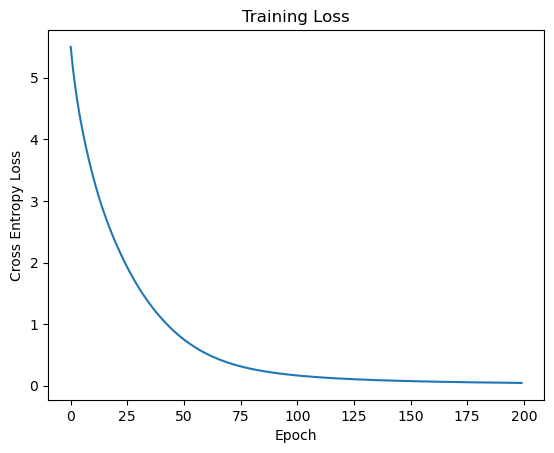

In [65]:
import matplotlib.pyplot as plt 

epochs = 200
learning_rate = 0.05
loss = []

model = CBOW(len(word_id), 10)

for e in range(epochs):
    loss_per_epoch = []
    for c, t in zip(context, target):
        y_pred = model.forward_pass(c)
        ce_loss = model.backward_pass(c, y_pred, t, learning_rate)
        loss_per_epoch.append(ce_loss)
    average_loss = np.mean(loss_per_epoch)
    if (e + 1) % 10 == 0:
        print(f"Epoch {e+1}/{epochs} | Loss: {average_loss:.4f}")
    loss.append(average_loss)

plt.plot(loss)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.show()


# Test 1 - Print similar words

In order to test my solution I wrote the functions below to see which words the model shows as similar. I then tested the model on a few words for which I expect other words to be correlated.

In [66]:

def get_embedding(word):
    one_hot = one_hot_encode(word_id[word], len(word_id))
    return one_hot @ model.w1 

def most_similar(word, top_n=3):
    vec = get_embedding(word)
    similarities = {}
    for w in word_id:
        if w == word:
            continue
        other = get_embedding(w)
        cos_sim = np.dot(vec, other) / (np.linalg.norm(vec) * np.linalg.norm(other)) # using formula (A dot B ) / magnitude(A) * magnitude(B)
        similarities[w] = cos_sim 
    return sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n] # returns [(word: value), ...]
test_words = ["vectors", "words", "google", "semantic", "model", "corrado", "mikolov",]
for word in test_words:
    if word in word_id:
        print(f"{word:12s} → Built: {most_similar(word, top_n=3)}")

vectors      → Built: [('chen', 0.7395131056030718), ('so', 0.5838142342006696), ('once', 0.5769990872555977)]
words        → Built: [('example', 0.6363453280659112), ('corpus', 0.6308253799213052), ('represents', 0.6080296457869006)]
google       → Built: [('chen', 0.5068072550160081), ('berlin', 0.47941259827040267), ('information', 0.47824218046882644)]
semantic     → Built: [('at', 0.8258287586370219), ('corrado', 0.7236182053682076), ('walk', 0.5610790284976591)]
model        → Built: [('synonymous', 0.7930541438014257), ('for', 0.6718508094900776), ('similarity', 0.5315854514576573)]
corrado      → Built: [('semantic', 0.7236182053682076), ('numbers', 0.7154608117060713), ('cosine', 0.5696107654781335)]
mikolov      → Built: [('by', 0.7128082342422115), ('mapped', 0.5461791636516438), ('greg', 0.5142673258696516)]


The model successfully learns word embeddings as demonstrated by the decreasing loss curve from 3.5 to 0.05 over 200 epochs. Similarity results show some semantically plausible relationships (mikolov → greg, corrado → semantic/cosine) though the small corpus limits the quality of embeddings. My hypothesis is that a larger corpus will most likely produce more meaningful embeddings.